<a href="https://colab.research.google.com/github/raja6294/Data_Analytics/blob/main/BCT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import json


try:

    with open('/content/raw_posts.json', 'r', encoding='utf-8', errors='ignore') as f:
        json_content = f.read()


    data = json.loads(json_content)
    df = pd.DataFrame(data)
except json.JSONDecodeError:
    data = []
    with open('/content/raw_posts.json', 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            try:
                data.append(json.loads(line))
            except json.JSONDecodeError:
                continue
    df = pd.DataFrame(data)
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    raise


print("Dataset Preview:")
print(df.head())
df['Platform'] = df['text'].apply(lambda x: 'LinkedIn' if 'LinkedIn' in str(x) else 'Other')

result = df.groupby('Platform')['engagement'].sum().reset_index()
result.rename(columns={'engagement': 'Total Engagement'}, inplace=True)

print("\nTotal Engagement per Platform:")
print(result)

if not result.empty:
    max_engagement_platform = result.loc[result['Total Engagement'].idxmax()]
    print("\nPlatform with Highest Engagement:", max_engagement_platform['Platform'], "(", max_engagement_platform['Total Engagement'], "total engagement )")
else:
    print("\nNo engagement data available for analysis.")


Dataset Preview:
                                                text  engagement
0  Just saw a LinkedIn Influencer with 'Organic G...          90
1  Jobseekers, this one’s for you.\n Every applic...         347
2  Looking for jobs on LinkedIn is like online da...         109
3  LinkedIn scams be like: 'Congratulations, you'...         115
4  sapne dekhna achi baat hai,\nlekin job ka sapn...         545

Total Engagement per Platform:
   Platform  Total Engagement
0  LinkedIn              2102
1     Other             23136

Platform with Highest Engagement: Other ( 23136 total engagement )


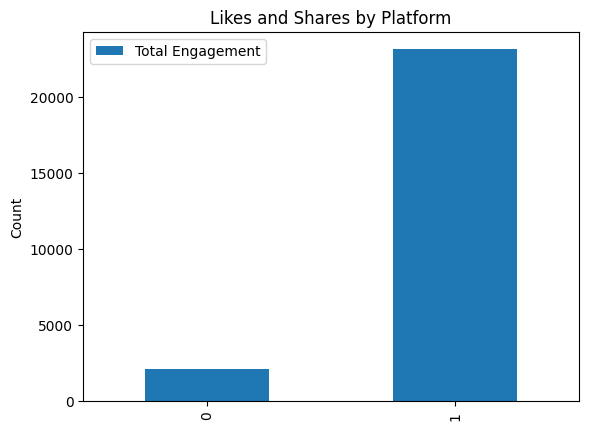

In [ ]:
import matplotlib.pyplot as plt

result.plot(kind='bar')
plt.title("Likes and Shares by Platform")
plt.ylabel("Count")
plt.show()

In [11]:
import seaborn as sns
import pandas as pd

# Load the Titanic dataset
titanic_df = sns.load_dataset('titanic')

# Display the first 5 rows of the DataFrame
print("Titanic Dataset Preview:")
display(titanic_df.head())
survival_rate_by_class = titanic_df.groupby('class')['survived'].mean()

Titanic Dataset Preview:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


/tmp/ipykernel_4222/692467435.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_rate_by_class = titanic_df.groupby('class')['survived'].mean()


In [14]:
sorted_age = titanic_df.sort_values("age")
print(sorted_age.head())

     survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
803         1       3    male  0.42      0      1   8.5167        C   Third   
755         1       2    male  0.67      1      1  14.5000        S  Second   
644         1       3  female  0.75      2      1  19.2583        C   Third   
469         1       3  female  0.75      2      1  19.2583        C   Third   
78          1       2    male  0.83      0      2  29.0000        S  Second   

       who  adult_male deck  embark_town alive  alone  
803  child       False  NaN    Cherbourg   yes  False  
755  child       False  NaN  Southampton   yes  False  
644  child       False  NaN    Cherbourg   yes  False  
469  child       False  NaN    Cherbourg   yes  False  
78   child       False  NaN  Southampton   yes  False  


In [17]:
sorted_fare = titanic_df.sort_values("fare",ascending=False)
print(sorted_fare.head())

     survived  pclass     sex   age  sibsp  parch      fare embarked  class  \
679         1       1    male  36.0      0      1  512.3292        C  First   
258         1       1  female  35.0      0      0  512.3292        C  First   
737         1       1    male  35.0      0      0  512.3292        C  First   
88          1       1  female  23.0      3      2  263.0000        S  First   
438         0       1    male  64.0      1      4  263.0000        S  First   

       who  adult_male deck  embark_town alive  alone  
679    man        True    B    Cherbourg   yes  False  
258  woman       False  NaN    Cherbourg   yes   True  
737    man        True    B    Cherbourg   yes   True  
88   woman       False    C  Southampton   yes  False  
438    man        True    C  Southampton    no  False  


In [19]:
df_indexed = titanic_df.set_index('who')
print(df_indexed.head())
set_index_df = df_indexed.loc['child']
print(set_index_df.head())

       survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
who                                                                            
man           0       3    male  22.0      1      0   7.2500        S  Third   
woman         1       1  female  38.0      1      0  71.2833        C  First   
woman         1       3  female  26.0      0      0   7.9250        S  Third   
woman         1       1  female  35.0      1      0  53.1000        S  First   
man           0       3    male  35.0      0      0   8.0500        S  Third   

       adult_male deck  embark_town alive  alone  
who                                               
man          True  NaN  Southampton    no  False  
woman       False    C    Cherbourg   yes  False  
woman       False  NaN  Southampton   yes   True  
woman       False    C  Southampton   yes  False  
man          True  NaN  Southampton    no   True  
       survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
w

     survived  pclass   sex   age  sibsp  parch     fare embarked  class  \
who                                                                        
man         0       3  male  22.0      1      0   7.2500        S  Third   
man         0       3  male  35.0      0      0   8.0500        S  Third   
man         0       3  male   NaN      0      0   8.4583        Q  Third   
man         0       1  male  54.0      0      0  51.8625        S  First   
man         0       3  male  20.0      0      0   8.0500        S  Third   

     adult_male deck  embark_town alive  alone  
who                                             
man        True  NaN  Southampton    no  False  
man        True  NaN  Southampton    no   True  
man        True  NaN   Queenstown    no   True  
man        True    E  Southampton    no   True  
man        True  NaN  Southampton    no   True  


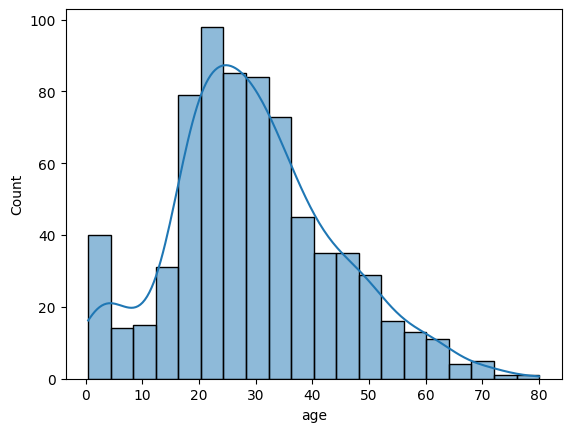

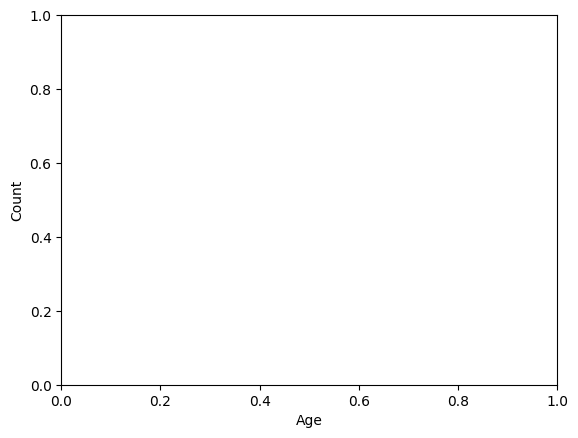

In [25]:
print(df_indexed.loc["man"].head())
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(titanic_df['age'], bins=20,kde=True)
plt.show("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()
kd=plt.pause


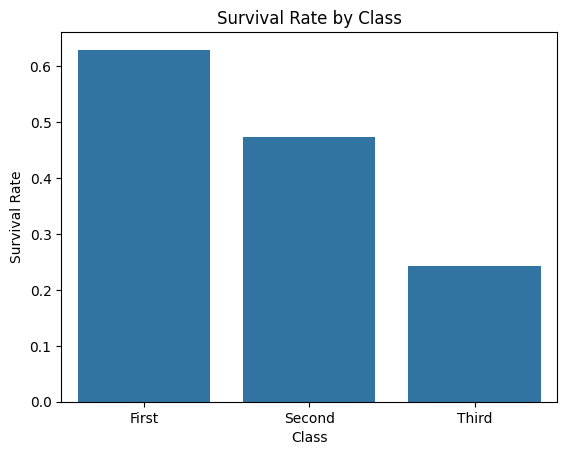

In [27]:
survival_rate_df = survival_rate_by_class.reset_index()
sns.barplot(x="class", y="survived", data=survival_rate_df)
plt.title("Survival Rate by Class")
plt.xlabel("Class")
plt.ylabel("Survival Rate")
plt.show()

Saving raw_posts.json to raw_posts (3).json
Original Data:
                                                text  engagement
0  Just saw a LinkedIn Influencer with 'Organic G...          90
1  Jobseekers, this one’s for you.\n Every applic...         347
2  Looking for jobs on LinkedIn is like online da...         109
3  LinkedIn scams be like: 'Congratulations, you'...         115
4  sapne dekhna achi baat hai,\nlekin job ka sapn...         545

Cleaned Data:
                                                text  engagement
0  Just saw a LinkedIn Influencer with 'Organic G...          90
1  Jobseekers, this one’s for you.\n Every applic...         347
2  Looking for jobs on LinkedIn is like online da...         109
3  LinkedIn scams be like: 'Congratulations, you'...         115
4  sapne dekhna achi baat hai,\nlekin job ka sapn...         545


/tmp/ipykernel_4222/76426240.py:33: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
/tmp/ipykernel_4222/76426240.py:36: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

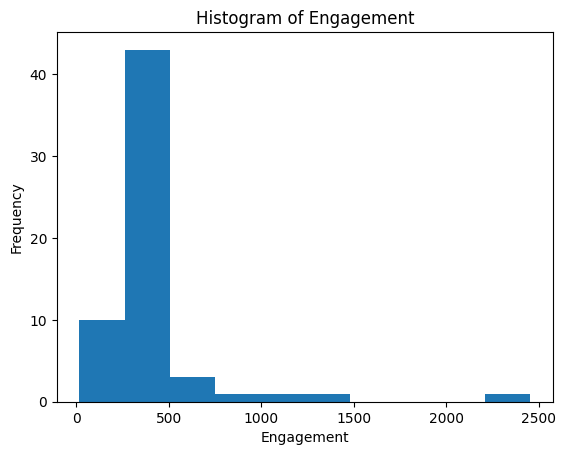

<Figure size 640x480 with 0 Axes>

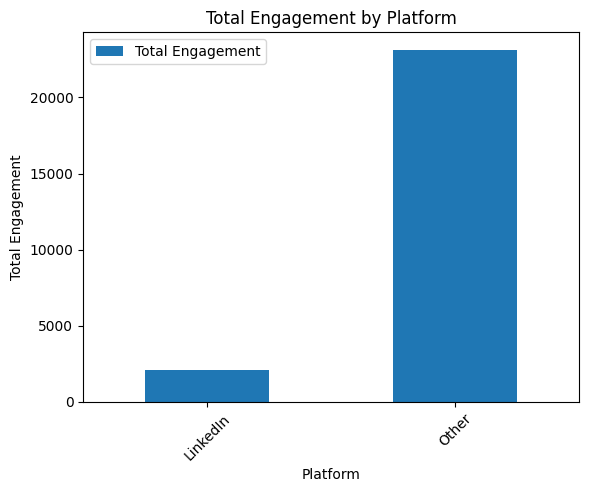

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import io
import json

from google.colab import files
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
json_content = uploaded[file_name].decode('utf-8', errors='ignore')

try:
    data = json.loads(json_content)
    df = pd.DataFrame(data)
except json.JSONDecodeError:
    data = []
    for line in io.StringIO(json_content):
        try:
            data.append(json.loads(line))
        except json.JSONDecodeError:
            continue
    df = pd.DataFrame(data)
except Exception as e:
    print(f"An unexpected error occurred during JSON parsing: {e}")
    raise

print("Original Data:")
print(df.head())

df = df.drop_duplicates()

for col in df.select_dtypes(include=['int64', 'float64']).columns:
    df[col].fillna(df[col].mean(), inplace=True)

for col in df.select_dtypes(include=['object']).columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\nCleaned Data:")
print(df.head())

# Create 'Platform' column based on 'text' content
df['Platform'] = df['text'].apply(lambda x: 'LinkedIn' if 'LinkedIn' in str(x) else 'Other')

plt.figure()
df['engagement'].plot(kind='hist', bins=10) # Changed to 'engagement'
plt.title("Histogram of Engagement") # Changed title
plt.xlabel("Engagement") # Changed label
plt.ylabel("Frequency")
plt.show()

result = df.groupby('Platform')['engagement'].sum().reset_index() # Changed to 'engagement' and added reset_index
result.rename(columns={'engagement': 'Total Engagement'}, inplace=True) # Rename for clarity

plt.figure()
result.plot(kind='bar', x='Platform', y='Total Engagement') # Specify x and y for plotting
plt.title("Total Engagement by Platform") # Changed title
plt.ylabel("Total Engagement") # Changed label
plt.xticks(rotation=45)
plt.show()

Saving raw_posts.json to raw_posts (6).json


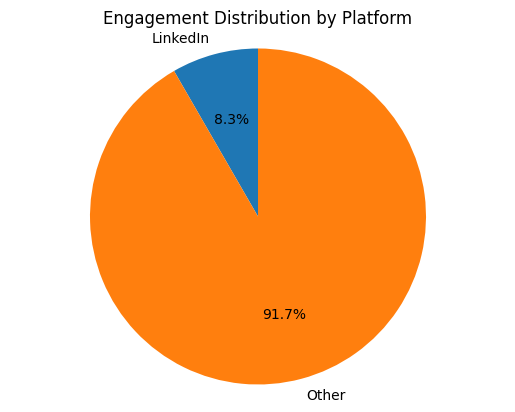

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import io
import json

from google.colab import files
uploaded = files.upload()


file_name = list(uploaded.keys())[0]
json_content = uploaded[file_name].decode('utf-8', errors='ignore')

try:
    data = json.loads(json_content)
    df = pd.DataFrame(data)
except json.JSONDecodeError:
    data = []
    for line in io.StringIO(json_content):
        try:
            data.append(json.loads(line))
        except json.JSONDecodeError:
            continue
    df = pd.DataFrame(data)
except Exception as e:
    print(f"An unexpected error occurred during JSON parsing: {e}")
    raise


df = df.drop_duplicates()
df.fillna(0, inplace=True)


if 'Platform' not in df.columns:
    df['Platform'] = df['text'].apply(lambda x: 'LinkedIn' if 'LinkedIn' in str(x) else 'Other')

result = df.groupby('Platform')['engagement'].sum()


plt.figure()
plt.pie(result, labels=result.index, autopct='%1.1f%%', startangle=90)
plt.title("Engagement Distribution by Platform")
plt.axis('equal')
plt.show()